# Reinforcement Learning — Tabular Q-Learning on FrozenLake
**Algorithm:** Value-based, Off-policy Q-Learning  
**Environment:** FrozenLake-v1 (Slippery & Non-Slippery)  
**Tools:** Python, NumPy, Gymnasium, Matplotlib  


## Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import gymnasium as gym
import os
import time

os.makedirs('outputs', exist_ok=True)

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor':  '#111111',
    'axes.facecolor':    '#1a1a1a',
    'axes.edgecolor':    '#2a2a2a',
    'axes.labelcolor':   '#cccccc',
    'xtick.color':       '#666666',
    'ytick.color':       '#666666',
    'text.color':        '#cccccc',
    'grid.color':        '#2a2a2a',
    'grid.linestyle':    '--',
    'legend.facecolor':  '#1a1a1a',
    'legend.edgecolor':  '#2a2a2a',
    'font.family':       'monospace',
})

print('Environment ready.')

Environment ready.


## Environment Exploration

In [2]:
env_demo = gym.make('FrozenLake-v1', is_slippery=False)

print('=== FrozenLake-v1 Environment ===')
print(f'States  : {env_demo.observation_space.n}')
print(f'Actions : {env_demo.action_space.n}  (0=Left, 1=Down, 2=Right, 3=Up)')
print(f'Grid    : 4x4')
print()
print('Map Layout:')
print('  S F F F')
print('  F H F H')
print('  F F F H')
print('  H F F G')
print()
print('S=Start  F=Frozen(safe)  H=Hole(fail)  G=Goal(+1 reward)')
env_demo.close()

=== FrozenLake-v1 Environment ===
States  : 16
Actions : 4  (0=Left, 1=Down, 2=Right, 3=Up)
Grid    : 4x4

Map Layout:
  S F F F
  F H F H
  F F F H
  H F F G

S=Start  F=Frozen(safe)  H=Hole(fail)  G=Goal(+1 reward)


## Hyperparameter Configuration

In [3]:
NON_SLIPPERY_CONFIG = {
    'alpha':         0.8,
    'gamma':         0.95,
    'epsilon_start': 1.0,
    'epsilon_end':   0.05,
    'epsilon_decay': 0.995,
    'n_episodes':    5000,
    'is_slippery':   False,
    'q_init':        0.5,
    'label':         'Non-Slippery',
    'color':         '#00d4a0',
}

SLIPPERY_CONFIG = {
    'alpha':         0.1,
    'gamma':         0.99,
    'epsilon_start': 1.0,
    'epsilon_end':   0.01,
    'epsilon_decay': 0.9995,
    'n_episodes':    20000,
    'is_slippery':   True,
    'q_init':        0.0,
    'label':         'Slippery',
    'color':         '#7c6aff',
}

print('Configs loaded.')


Configs loaded.


## Q-Learning Agent (Value-Based, Off-Policy)

In [4]:
class QLearningAgent:

    # Initialize Q-table and epsilon
    def __init__(self, n_states, n_actions, config):
        self.Q             = np.ones((n_states, n_actions)) * config['q_init']
        self.alpha         = config['alpha']
        self.gamma         = config['gamma']
        self.epsilon       = config['epsilon_start']
        self.epsilon_end   = config['epsilon_end']
        self.epsilon_decay = config['epsilon_decay']
        self.epsilon_log   = []

    # Select action using epsilon-greedy strategy
    def choose_action(self, state, n_actions):
        if np.random.random() < self.epsilon:
            return np.random.randint(n_actions)
        return int(np.argmax(self.Q[state]))

    # Apply Bellman TD update (off-policy: uses max over next state)
    def update(self, s, a, r, s_next, done):
        future = 0 if done else np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (r + self.gamma * future - self.Q[s, a])

    # Decay epsilon after each episode
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        self.epsilon_log.append(self.epsilon)

print('QLearningAgent defined.')


QLearningAgent defined.


## Training Loop

In [5]:
# Run full training and return agent + metrics
def train(config):
    env   = gym.make('FrozenLake-v1', is_slippery=config['is_slippery'])
    env.reset(seed=SEED)
    agent = QLearningAgent(
        env.observation_space.n,
        env.action_space.n,
        config
    )

    rewards       = []
    steps_log     = []
    visit_counts  = np.zeros(env.observation_space.n)

    for episode in range(config['n_episodes']):
        state, _ = env.reset()
        total_reward = 0
        steps        = 0

        for _ in range(200):
            action              = agent.choose_action(state, env.action_space.n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done                = terminated or truncated

            agent.update(state, action, reward, next_state, done)
            visit_counts[state] += 1

            state        = next_state
            total_reward += reward
            steps        += 1

            if done:
                break

        agent.decay_epsilon()
        rewards.append(total_reward)
        steps_log.append(steps)

        if (episode + 1) % 1000 == 0:
            avg = np.mean(rewards[-1000:])
            print(f"[{config['label']}] Episode {episode+1:>6} | "
                  f"Avg Reward: {avg:.3f} | Epsilon: {agent.epsilon:.4f}")

    env.close()
    return agent, rewards, steps_log, visit_counts


# Evaluate greedy policy (epsilon=0) for 100 episodes
def evaluate(config, agent):
    env     = gym.make('FrozenLake-v1', is_slippery=config['is_slippery'])
    env.reset(seed=9999)
    wins    = 0
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    for ep in range(100):
        state, _ = env.reset()
        for _ in range(200):
            action = agent.choose_action(state, env.action_space.n)
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                wins += int(reward == 1.0)
                break

    agent.epsilon = old_eps
    env.close()
    return wins

print('Training functions ready.')


Training functions ready.


In [6]:
print('Training Non-Slippery...')
t0 = time.time()
agent_ns, rewards_ns, steps_ns, visits_ns = train(NON_SLIPPERY_CONFIG)
print(f'Done in {time.time()-t0:.1f}s\n')

print('Training Slippery...')
t0 = time.time()
agent_sl, rewards_sl, steps_sl, visits_sl = train(SLIPPERY_CONFIG)
print(f'Done in {time.time()-t0:.1f}s')

Training Non-Slippery...
[Non-Slippery] Episode   1000 | Avg Reward: 0.749 | Epsilon: 0.0500
[Non-Slippery] Episode   2000 | Avg Reward: 0.939 | Epsilon: 0.0500
[Non-Slippery] Episode   3000 | Avg Reward: 0.952 | Epsilon: 0.0500
[Non-Slippery] Episode   4000 | Avg Reward: 0.957 | Epsilon: 0.0500
[Non-Slippery] Episode   5000 | Avg Reward: 0.945 | Epsilon: 0.0500
Done in 1.2s

Training Slippery...
[Slippery] Episode   1000 | Avg Reward: 0.029 | Epsilon: 0.6065
[Slippery] Episode   2000 | Avg Reward: 0.075 | Epsilon: 0.3678
[Slippery] Episode   3000 | Avg Reward: 0.148 | Epsilon: 0.2230
[Slippery] Episode   4000 | Avg Reward: 0.259 | Epsilon: 0.1353
[Slippery] Episode   5000 | Avg Reward: 0.366 | Epsilon: 0.0820
[Slippery] Episode   6000 | Avg Reward: 0.489 | Epsilon: 0.0497
[Slippery] Episode   7000 | Avg Reward: 0.533 | Epsilon: 0.0302
[Slippery] Episode   8000 | Avg Reward: 0.573 | Epsilon: 0.0183
[Slippery] Episode   9000 | Avg Reward: 0.643 | Epsilon: 0.0111
[Slippery] Episode  1000

## Evaluation & Logs

In [7]:
wins_ns = evaluate(NON_SLIPPERY_CONFIG, agent_ns)
wins_sl = evaluate(SLIPPERY_CONFIG,     agent_sl)

log_lines = [
    '=== Q-Learning Evaluation — Last 100 Episodes ===',
    f'Non-Slippery  Success Rate : {wins_ns}/100  ({wins_ns}%)',
    f'Slippery      Success Rate : {wins_sl}/100  ({wins_sl}%)',
    '',
    f'Non-Slippery  Final Epsilon: {agent_ns.epsilon:.4f}',
    f'Slippery      Final Epsilon: {agent_sl.epsilon:.4f}',
    '',
    f'Non-Slippery  Avg Reward (last 1000 ep): {np.mean(rewards_ns[-1000:]):.4f}',
    f'Slippery      Avg Reward (last 1000 ep): {np.mean(rewards_sl[-1000:]):.4f}',
]

for line in log_lines:
    print(line)

with open('outputs/logs.txt', 'w') as f:
    f.write('\n'.join(log_lines))

print('\nLogs saved to outputs/logs.txt')

=== Q-Learning Evaluation — Last 100 Episodes ===
Non-Slippery  Success Rate : 100/100  (100%)
Slippery      Success Rate : 77/100  (77%)

Non-Slippery  Final Epsilon: 0.0500
Slippery      Final Epsilon: 0.0100

Non-Slippery  Avg Reward (last 1000 ep): 0.9450
Slippery      Avg Reward (last 1000 ep): 0.6730

Logs saved to outputs/logs.txt


## Visualizations

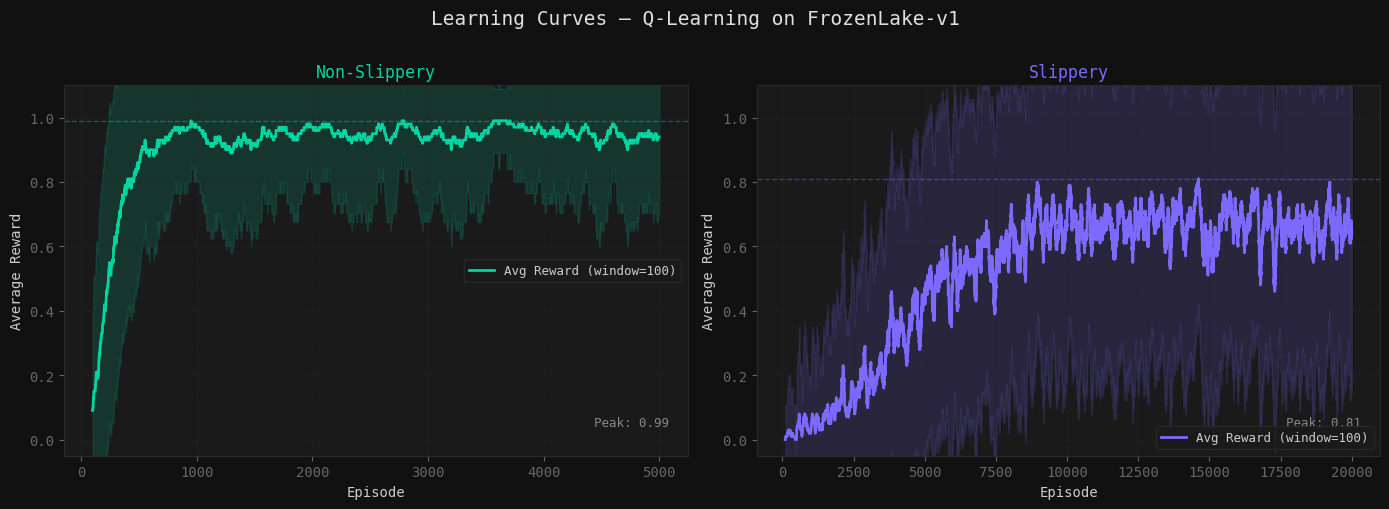

Saved: outputs/learning_curves.png


In [8]:
# Compute rolling average over a window
def rolling(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')


# ── Plot 1: Learning Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Q-Learning on FrozenLake-v1',
             fontsize=14, color='#e0e0e0', y=1.01)

for ax, rewards, config, agent in [
    (axes[0], rewards_ns, NON_SLIPPERY_CONFIG, agent_ns),
    (axes[1], rewards_sl, SLIPPERY_CONFIG,     agent_sl),
]:
    color  = config['color']
    smooth = rolling(rewards, 100)
    ep_x   = np.arange(len(smooth)) + 100

    std    = np.array([
        np.std(rewards[max(0,i-100):i+1])
        for i in range(99, len(rewards))
    ])

    ax.fill_between(ep_x, smooth - std, smooth + std,
                    alpha=0.15, color=color)
    ax.plot(ep_x, smooth, color=color, linewidth=2,
            label='Avg Reward (window=100)')
    ax.axhline(np.max(smooth), color=color, linestyle='--',
               alpha=0.4, linewidth=1)

    ax.set_title(config['label'], color=color, fontsize=12)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average Reward')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    peak = np.max(smooth)
    ax.text(0.97, 0.08, f'Peak: {peak:.2f}',
            transform=ax.transAxes, ha='right',
            fontsize=9, color='#888888')

plt.tight_layout()
plt.savefig('outputs/learning_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/learning_curves.png')

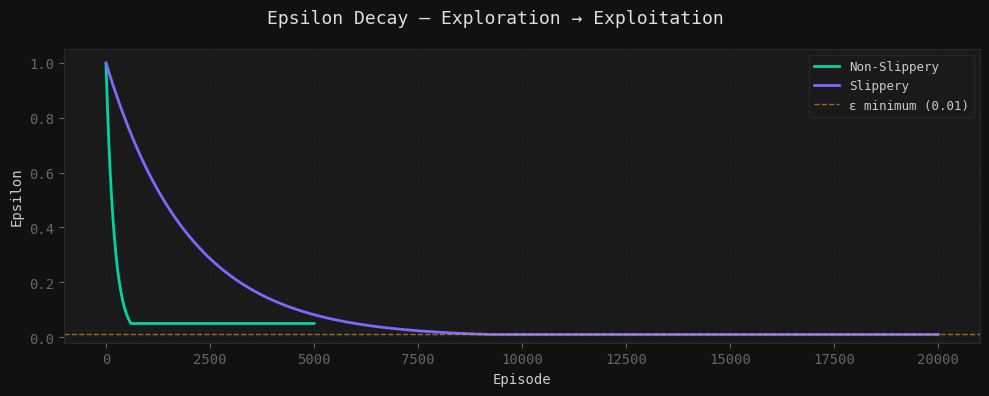

Saved: outputs/epsilon_decay.png


In [9]:
# ── Plot 2: Epsilon Decay ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Epsilon Decay — Exploration → Exploitation',
             fontsize=13, color='#e0e0e0')

ax.plot(agent_ns.epsilon_log, color='#00d4a0', linewidth=2,
        label='Non-Slippery')
ax.plot(agent_sl.epsilon_log, color='#7c6aff', linewidth=2,
        label='Slippery')

ax.axhline(0.01, color='#f5a623', linestyle='--',
           linewidth=1, alpha=0.6, label='ε minimum (0.01)')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/epsilon_decay.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/epsilon_decay.png')

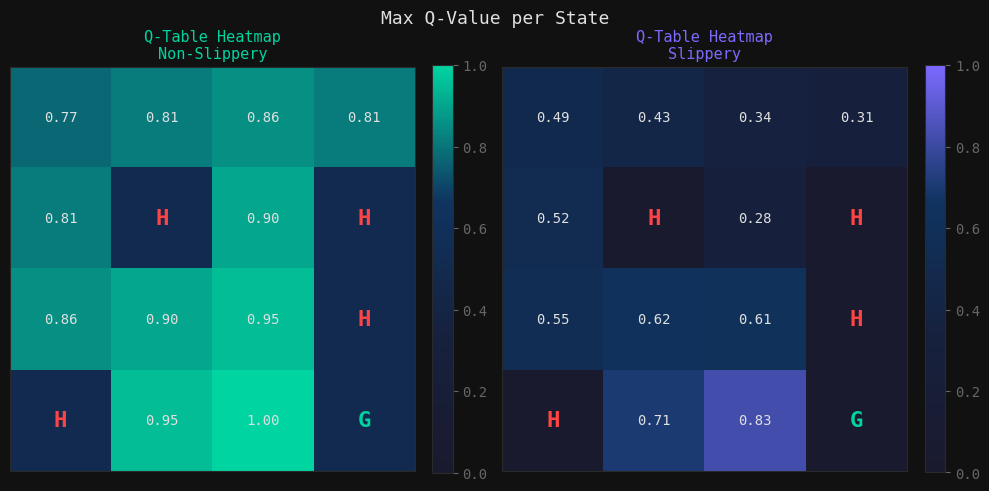

Saved: outputs/qTable_heatmap.png


In [10]:
# ── Plot 3: Q-Table Heatmaps ─────────────────────────────────────────────────
GRID        = 4
HOLES       = [5, 7, 11, 12]
GOAL        = 15
ACTION_SYMS = ['←', '↓', '→', '↑']

# Draw one heatmap panel
def draw_heatmap(ax, agent, config):
    max_q = np.max(agent.Q, axis=1).reshape(GRID, GRID)
    cmap  = mcolors.LinearSegmentedColormap.from_list(
        'rl', ['#1a1a2e', '#16213e', '#0f3460', config['color']])
    im = ax.imshow(max_q, cmap=cmap, vmin=0, vmax=1)

    for r in range(GRID):
        for c in range(GRID):
            idx = r * GRID + c
            if idx in HOLES:
                ax.text(c, r, 'H', ha='center', va='center',
                        fontsize=16, color='#ff4444', fontweight='bold')
            elif idx == GOAL:
                ax.text(c, r, 'G', ha='center', va='center',
                        fontsize=16, color='#00d4a0', fontweight='bold')
            else:
                ax.text(c, r, f'{max_q[r,c]:.2f}',
                        ha='center', va='center',
                        fontsize=10, color='#e0e0e0')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Q-Table Heatmap\n{config["label"]}',
                 color=config['color'], fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Max Q-Value per State', fontsize=13, color='#e0e0e0')

draw_heatmap(axes[0], agent_ns, NON_SLIPPERY_CONFIG)
draw_heatmap(axes[1], agent_sl, SLIPPERY_CONFIG)

plt.tight_layout()
plt.savefig('outputs/qTable_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/qTable_heatmap.png')

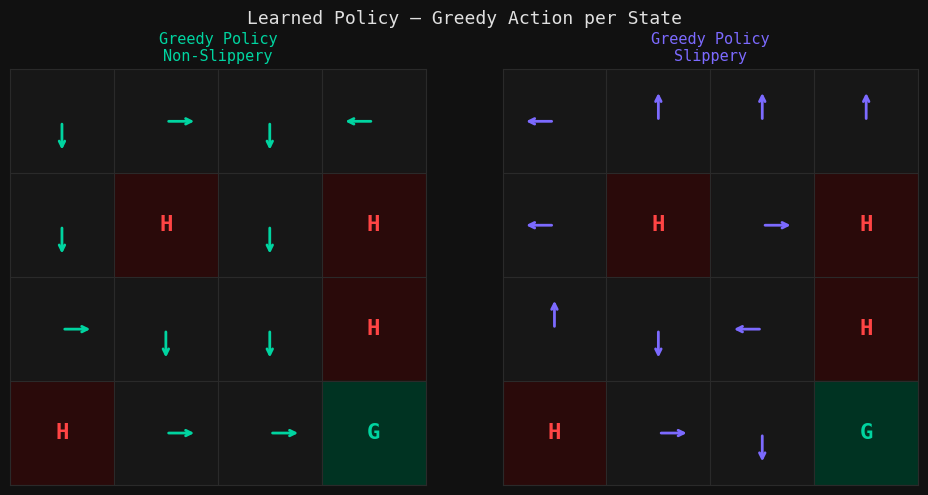

Saved: outputs/policy_arrows.png


In [11]:
# ── Plot 4: Policy Arrow Maps ─────────────────────────────────────────────────
ARROW_DX = {'←': -0.3, '↓': 0, '→': 0.3, '↑': 0}
ARROW_DY = {'←': 0,    '↓': 0.3,'→': 0,  '↑': -0.3}

# Draw greedy policy as arrows on the grid
def draw_policy(ax, agent, config):
    background = np.zeros((GRID, GRID))
    ax.imshow(background, cmap='gray', vmin=0, vmax=1, alpha=0.1)

    for r in range(GRID):
        for c in range(GRID):
            idx = r * GRID + c
            if idx in HOLES:
                ax.add_patch(plt.Rectangle(
                    (c-0.5, r-0.5), 1, 1,
                    color='#2a0a0a', zorder=1))
                ax.text(c, r, 'H', ha='center', va='center',
                        fontsize=16, color='#ff4444',
                        fontweight='bold', zorder=2)
            elif idx == GOAL:
                ax.add_patch(plt.Rectangle(
                    (c-0.5, r-0.5), 1, 1,
                    color='#003322', zorder=1))
                ax.text(c, r, 'G', ha='center', va='center',
                        fontsize=16, color='#00d4a0',
                        fontweight='bold', zorder=2)
            else:
                best   = int(np.argmax(agent.Q[idx]))
                symbol = ACTION_SYMS[best]
                dx     = ARROW_DX[symbol]
                dy     = ARROW_DY[symbol]
                ax.annotate('', xy=(c+dx, r+dy), xytext=(c, r),
                            arrowprops=dict(
                                arrowstyle='->', color=config['color'],
                                lw=2), zorder=2)

    for i in range(GRID + 1):
        ax.axhline(i - 0.5, color='#2a2a2a', linewidth=0.8)
        ax.axvline(i - 0.5, color='#2a2a2a', linewidth=0.8)

    ax.set_xlim(-0.5, GRID - 0.5)
    ax.set_ylim(GRID - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Greedy Policy\n{config["label"]}',
                 color=config['color'], fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Learned Policy — Greedy Action per State',
             fontsize=13, color='#e0e0e0')

draw_policy(axes[0], agent_ns, NON_SLIPPERY_CONFIG)
draw_policy(axes[1], agent_sl, SLIPPERY_CONFIG)

plt.tight_layout()
plt.savefig('outputs/policy_arrows.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/policy_arrows.png')

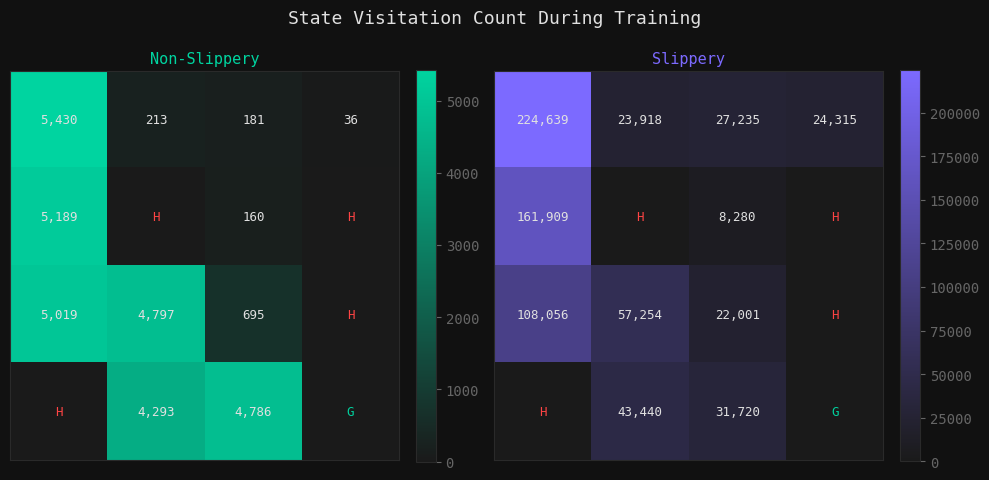

Saved: outputs/state_visitation.png


In [12]:
# ── Plot 5: State Visitation Heatmap ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('State Visitation Count During Training',
             fontsize=13, color='#e0e0e0')

for ax, visits, config in [
    (axes[0], visits_ns, NON_SLIPPERY_CONFIG),
    (axes[1], visits_sl, SLIPPERY_CONFIG),
]:
    grid = visits.reshape(GRID, GRID)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'visits', ['#1a1a1a', config['color']])
    im = ax.imshow(grid, cmap=cmap)

    for r in range(GRID):
        for c in range(GRID):
            idx = r * GRID + c
            label = 'H' if idx in HOLES else 'G' if idx == GOAL else f'{int(grid[r,c]):,}'
            color = '#ff4444' if idx in HOLES else '#00d4a0' if idx == GOAL else '#e0e0e0'
            ax.text(c, r, label, ha='center', va='center',
                    fontsize=9, color=color)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(config['label'], color=config['color'], fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('outputs/state_visitation.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/state_visitation.png')

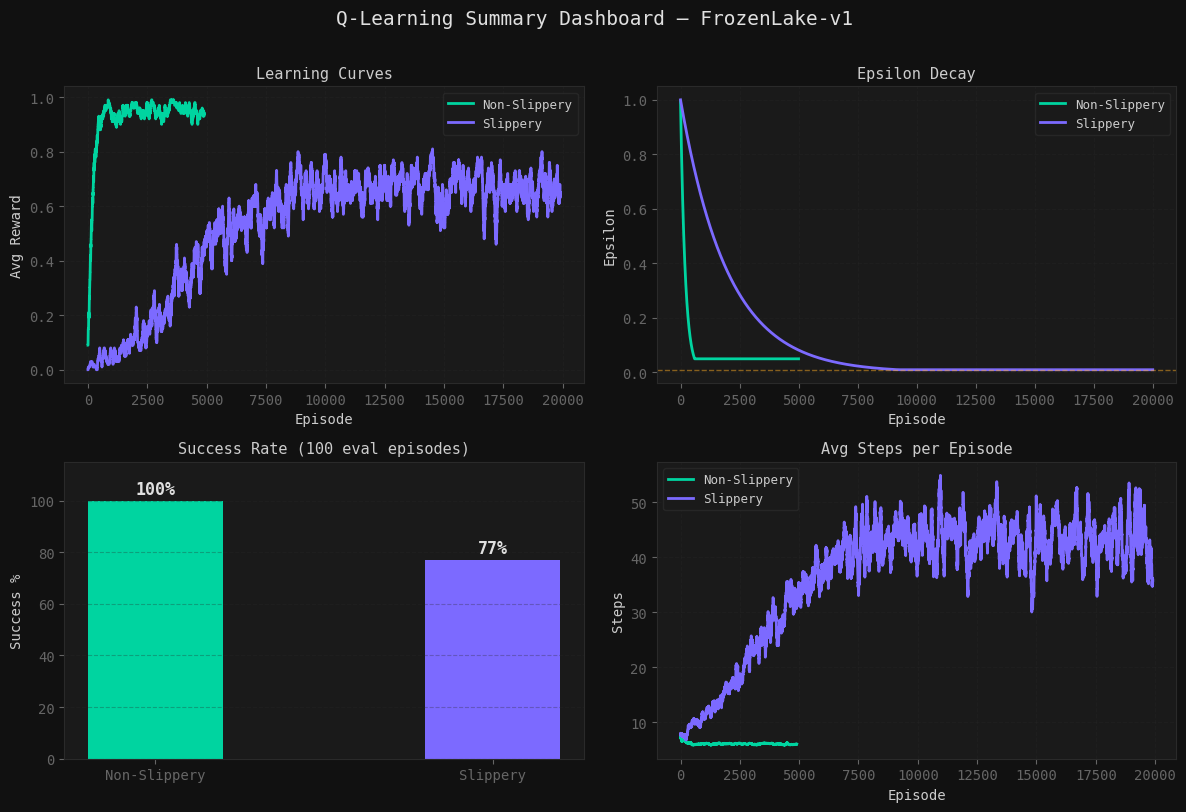

Saved: outputs/summary_dashboard.png


In [13]:
# ── Plot 6: Summary Dashboard ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Q-Learning Summary Dashboard — FrozenLake-v1',
             fontsize=14, color='#e0e0e0', y=1.01)

smooth_ns = rolling(rewards_ns, 100)
smooth_sl = rolling(rewards_sl, 100)

# Top-left: combined learning curves
ax = axes[0][0]
ax.plot(smooth_ns, color='#00d4a0', linewidth=2, label='Non-Slippery')
ax.plot(smooth_sl, color='#7c6aff', linewidth=2, label='Slippery')
ax.set_title('Learning Curves', color='#cccccc', fontsize=11)
ax.set_xlabel('Episode')
ax.set_ylabel('Avg Reward')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Top-right: epsilon decay
ax = axes[0][1]
ax.plot(agent_ns.epsilon_log, color='#00d4a0', linewidth=2, label='Non-Slippery')
ax.plot(agent_sl.epsilon_log, color='#7c6aff', linewidth=2, label='Slippery')
ax.axhline(0.01, color='#f5a623', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Epsilon Decay', color='#cccccc', fontsize=11)
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom-left: success rate bar
ax = axes[1][0]
bars = ax.bar(['Non-Slippery', 'Slippery'], [wins_ns, wins_sl],
               color=['#00d4a0', '#7c6aff'], width=0.4)
for bar, val in zip(bars, [wins_ns, wins_sl]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=12,
            color='#e0e0e0', fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('Success Rate (100 eval episodes)', color='#cccccc', fontsize=11)
ax.set_ylabel('Success %')
ax.grid(True, alpha=0.3, axis='y')

# Bottom-right: avg steps per episode
ax = axes[1][1]
smooth_steps_ns = rolling(steps_ns, 100)
smooth_steps_sl = rolling(steps_sl, 100)
ax.plot(smooth_steps_ns, color='#00d4a0', linewidth=2, label='Non-Slippery')
ax.plot(smooth_steps_sl, color='#7c6aff', linewidth=2, label='Slippery')
ax.set_title('Avg Steps per Episode', color='#cccccc', fontsize=11)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved: outputs/summary_dashboard.png')

In [14]:
print('=== Final Summary ===')
print(f'Non-Slippery  Success Rate : {wins_ns}/100  ({wins_ns}%)')
print(f'Slippery      Success Rate : {wins_sl}/100  ({wins_sl}%)')
print()
print('Output files:')
for f in os.listdir('outputs'):
    print(f'  outputs/{f}')


=== Final Summary ===
Non-Slippery  Success Rate : 100/100  (100%)
Slippery      Success Rate : 77/100  (77%)

Output files:
  outputs/logs.txt
  outputs/summary_dashboard.png
  outputs/policy_arrows.png
  outputs/epsilon_decay.png
  outputs/state_visitation.png
  outputs/learning_curves.png
  outputs/qTable_heatmap.png
